# Predicción de mora temprana en microcréditos MYPE
**Notebook 01 · Problema, dataset y análisis exploratorio**


## 1. Definición del problema

**Contexto:** 

Las microfinancieras peruanas en su mayoria son cajas municipales que financian a micro y pequeñas empresas (MYPE) que en muchas ocasiones funcionan de manera informal y no cuentan con registros financieros ordenados. Ademas, generar una buena evaluacion crediticia es dificil, pues la estimacion del asesor de negocios depende de la información declarada por el cliente, lo cual, a su vez, genera dificultad de anticipar qué creditos no seran pagados. Ademas, se sabe que en los ultimos años la morosidad de las microempresas ha aumentado, obligando a las entidades a constituir mayores provisiones y reduciendo su rentabilidad para las MYPEs.

**Necesidad.** El comite de creditos necesita una estimacion objetiva del riesgo de mora de cada solicitud, construida con la información disponible al momento de la evaluacion, que complemente el analisis del asesor.


**Unidad de análisis.** Un credito MYPE desembolsado. Un mismo cliente puede tener varios creditos.

**Pregunta principal.** ¿Puede un modelo estimar, al momento de la evaluacion, la probabilidad de que un credito MYPE supere los 30 dias de atraso en sus primeros 6 meses, mejor que una regla simple?

![Línea de decisión de un microcrédito](..\reports\figures\LineaPrestamo.png)


**Tipo de problema.** Clasificacion binaria supervisada. La variable objetivo toma el valor 1 si el credito registra mas de 30 dias de atraso en algun momento de sus primeros 6 meses desde el desembolso, y 0 en caso contrario. Las clases estan desbalanceadas (~11 % de creditos en mora). El umbral de 30 dias coincide con el paso de un deudor a la categoria "Deficiente" en la clasificacion de la SBS para microempresas.

**Usuario y uso.** El comite de creditos. Para cada solicitud, el modelo entrega una probabilidad de mora que complementa el analisis del asesor de negocios. Solo utiliza variables conocidas antes del desembolso, de modo que pueda aplicarse en la evaluacion real. La decision final de aprobar, ajustar o rechazar sigue siendo del comite.

**Utilidad esperada.** Identificar con anticipacion las solicitudes de mayor riesgo para ajustar sus condiciones (monto, plazo, garantias) o reforzar su evaluacion, reduciendo la mora y las provisiones asociadas sin restringir innecesariamente el acceso al credito de los buenos pagadores.

**Criterios de utilidad.** Aprobar a un cliente que cae en mora (falso negativo) es mas costoso que rechazar a un buen pagador (falso positivo), porque implica perder capital y no solo intereses. Por ello, el resultado se considerara util si:
- supera claramente al baseline en metricas adecuadas al desbalance (por ejemplo, AUC-ROC, AUC-PR), y no solo en accuracy
- detecta una proporcion relevante de los creditos que caen en mora
- mantiene un nivel razonable de falsos positivos, para no rechazar en exceso a buenos pagadores


## 2. Dataset y procedencia

- **Fuente y procedencia:** dataset sintético generado por el grupo , con autorización del docente, que simula la cartera de créditos MYPE desembolsados por una entidad microfinanciera peruana.
- **Período temporal:** según el diccionario, desembolsos entre enero de 2022 y diciembre de 2024, con corte de extracción al 30/06/2025. El rango real y la posible presencia de fechas mal registradas se verifican en la ficha.
- **Variable objetivo:** `mora_30d_6m` (binaria): 1 si el crédito superó 30 días de atraso dentro de sus primeros 6 meses desde el desembolso, 0 en caso contrario. 
- **Variables principales** :
  - *Perfil del titular:* edad, sexo, estado_civil, nivel_educativo, tipo_vivienda, num_dependientes.
  - *Negocio:* rubro, antiguedad_negocio_meses, ingreso_mensual_declarado, gasto_mensual_declarado.
  - *Historial crediticio:* score_buro, calificacion_sbs, max_dias_atraso_12m, num_entidades_sistema, deuda_total_sistema, num_consultas_buro_6m, cliente_recurrente, num_creditos_previos_entidad.
  - *Condiciones del crédito:* monto_solicitado, monto_aprobado, plazo_meses, tasa_interes_anual, cuota_mensual, tiene_garantia.
  - *Operación:* region, canal_captacion, codigo_asesor, telefono_verificado.
  - *Identificadores y fechas:* id_credito, id_cliente, fecha_solicitud, fecha_desembolso.
  - *Posteriores al desembolso:* num_gestiones_cobranza, estado_credito_corte.
- **Licencia o condiciones de uso:** al ser generado por el propio grupo, no está sujeto a licencias de terceros; su uso está autorizado en el marco del curso.
- **Limitaciones conocidas:**
  1. *Datos sintéticos:* las relaciones que se encuentren reflejan las reglas del generador, no necesariamente el comportamiento real de los microempresarios. Las conclusiones no pueden extrapolarse a la población real.
  2. *Variables posteriores al desembolso:* `num_gestiones_cobranza` (registrada hasta la fecha de corte) y `estado_credito_corte` contienen información que no existe al momento de evaluar la solicitud. Usarlas como predictores sería data leakage; se describen pero no deberán entrar al modelo.
  3. *Variables definidas por la propia entidad:* `monto_aprobado`, `tasa_interes_anual` y `cuota_mensual` son decididas por el comité; la tasa podría reflejar ya una evaluación de riesgo previa. Se analizará su uso con cuidado.
  4. *Varios créditos por cliente:* un mismo `id_cliente` puede aparecer varias veces; si queda en train y test a la vez, la evaluación podría ser optimista.
  5. *Sesgo de selección:* solo se observan créditos desembolsados; no hay información de solicitudes rechazadas.
- **Justificación:** el dataset tiene una variable objetivo definida y alineada con el criterio SBS (más de 30 días de atraso = categoría "Deficiente"), variables disponibles al momento de la evaluación (perfil, negocio, historial y condiciones del crédito) y un volumen suficiente para separar train/validation/test, lo que permite responder la pregunta planteada en la sección 1.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw/creditos_mype.csv")
df.shape

(15579, 35)

In [2]:
# Inspección inicial: tipos de cada columna y primeras filas
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15579 entries, 0 to 15578
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_credito                    15579 non-null  object 
 1   id_cliente                    15579 non-null  object 
 2   fecha_solicitud               15579 non-null  object 
 3   fecha_desembolso              15579 non-null  object 
 4   region                        15579 non-null  object 
 5   codigo_asesor                 15579 non-null  object 
 6   canal_captacion               15579 non-null  object 
 7   edad                          15579 non-null  int64  
 8   sexo                          15579 non-null  object 
 9   estado_civil                  15579 non-null  object 
 10  nivel_educativo               14294 non-null  object 
 11  tipo_vivienda                 15579 non-null  object 
 12  num_dependientes              15579 non-null  int64  
 13  r

,id_credito,id_cliente,fecha_solicitud,fecha_desembolso,region,codigo_asesor,canal_captacion,edad,sexo,estado_civil,nivel_educativo,tipo_vivienda,num_dependientes,rubro,antiguedad_negocio_meses,ingreso_mensual_declarado,gasto_mensual_declarado,cliente_recurrente,num_creditos_previos_entidad,score_buro,calificacion_sbs,max_dias_atraso_12m,num_entidades_sistema,deuda_total_sistema,num_consultas_buro_6m,monto_solicitado,monto_aprobado,plazo_meses,tasa_interes_anual,cuota_mensual,tiene_garantia,telefono_verificado,num_gestiones_cobranza,estado_credito_corte,mora_30d_6m
0,CR2012615,CL109437,2024-10-21,2024-10-29,Lima,AS039,Asesor de campo,59,Masculino,Casado,Primaria,Propia,0,Servicios,213.0,3940.0,1700.0,No,0,752.0,Normal,9,4,27110.0,5,4000.0,4000.0,18,52.29,304.96,No,Si,0,Vigente,0
1,CR2002778,CL102078,2022-08-30,2022-09-04,Loreto,AS004,Asesor de campo,42,M,Casado,Tecnica,Alquilada,1,Servicios,44.0,1830.0,1020.0,Si,1,596.0,Normal,45,2,1970.0,0,1300.0,1100.0,12,61.53,117.73,No,Si,0,Cancelado,0
2,CR2013067,CL109770,25/05/2024,09/06/2024,Loreto,AS015,Agencia,39,Masculino,Casado,Primaria,Alquilada,2,Agropecuario,71.0,2410.0,1700.0,No,0,NaN,Sin historial,0,0,0.0,1,1900.0,1900.0,12,57.18,200.58,No,Si,0,Cancelado,0
3,CR2013540,CL110113,2023-05-29,2023-06-01,Arequipa,AS045,Asesor de campo,26,F,Casado,Secundaria,Familiar,0,Comercio,24.0,4850.0,NaN,No,0,635.0,Normal,27,1,8260.0,2,7300.0,7300.0,9,55.95,971.65,No,Si,0,Cancelado,0
4,CR2006412,CL104797,2024-02-05,2024-02-09,Junin,DIGITAL,Digital,48,Femenino,Conviviente,Tecnica,Familiar,3,Agropecuario,38.0,4660.0,1970.0,No,0,765.0,Normal,0,2,11840.0,0,4300.0,4300.0,9,55.32,571.42,Si,No,0,Cancelado,0


In [3]:
# Valores faltantes por columna (solo columnas con al menos un faltante)
faltantes = df.isna().sum()
display(faltantes[faltantes > 0].to_frame("Faltantes"))
print(df.dtypes.to_string())

,Faltantes
nivel_educativo,1285
antiguedad_negocio_meses,671
ingreso_mensual_declarado,391
gasto_mensual_declarado,626
score_buro,2417
telefono_verificado,466


id_credito                       object
id_cliente                       object
fecha_solicitud                  object
fecha_desembolso                 object
region                           object
codigo_asesor                    object
canal_captacion                  object
edad                              int64
sexo                             object
estado_civil                     object
nivel_educativo                  object
tipo_vivienda                    object
num_dependientes                  int64
rubro                            object
antiguedad_negocio_meses        float64
ingreso_mensual_declarado        object
gasto_mensual_declarado         float64
cliente_recurrente               object
num_creditos_previos_entidad      int64
score_buro                      float64
calificacion_sbs                 object
max_dias_atraso_12m               int64
num_entidades_sistema             int64
deuda_total_sistema             float64
num_consultas_buro_6m             int64


In [4]:
# Ficha del dataset (todos los números salen del código)
fechas = pd.to_datetime(df["fecha_desembolso"], errors="coerce")
no_convertibles = fechas.isna() & df["fecha_desembolso"].notna()

ficha = pd.Series({
    "Observaciones (filas)": df.shape[0],
    "Variables (columnas)": df.shape[1],
    "Créditos únicos (id_credito)": df["id_credito"].nunique(),
    "Clientes únicos (id_cliente)": df["id_cliente"].nunique(),
    "Primer desembolso": fechas.min(),
    "Último desembolso": fechas.max(),
    "Fechas de desembolso vacías": int(df["fecha_desembolso"].isna().sum()),
    "Fechas de desembolso no convertibles": int(no_convertibles.sum()),
    "¿Último desembolso + 6 meses <= corte (30/06/2025)?": (fechas.max() + pd.DateOffset(months=6)) <= pd.Timestamp("2025-06-30"),
})
display(ficha.to_frame("Valor"))

print("Ejemplos de fechas en el archivo:", df["fecha_desembolso"].head(5).tolist())
print("Ejemplos de fechas no convertibles:", df.loc[no_convertibles, "fecha_desembolso"].head(10).tolist())

,Valor
Observaciones (filas),15579
Variables (columnas),35
Créditos únicos (id_credito),15395
Clientes únicos (id_cliente),11500
Primer desembolso,2022-01-01 00:00:00
Último desembolso,2024-12-30 00:00:00
Fechas de desembolso vacías,0
Fechas de desembolso no convertibles,1890
¿Último desembolso + 6 meses <= corte (30/06/2025)?,True


Ejemplos de fechas en el archivo: ['2024-10-29', '2022-09-04', '09/06/2024', '2023-06-01', '2024-02-09']
Ejemplos de fechas no convertibles: ['09/06/2024', '23/07/2023', '04/09/2022', '20/10/2023', '21/03/2024', '03/09/2023', '27/11/2024', '13/04/2023', '21/07/2022', '28/01/2024']


**Lectura de la ficha y de la inspección inicial**

Lo que muestran los datos:
- El número de `id_credito` únicos es menor que el número de filas: existen registros duplicados de créditos (a verificar en el notebook 02 si son copias exactas o el mismo identificador con datos distintos).
- El número de `id_cliente` únicos es menor que el de créditos: varios clientes tienen más de un crédito, lo que confirma la limitación 4.
- Las fechas aparecen en dos formatos, `AAAA-MM-DD` y `DD/MM/AAAA`. Las del segundo formato no se convierten automáticamente (ver "Fechas de desembolso no convertibles"). El mismo problema se observa en `fecha_solicitud`.
- Entre las fechas que sí se convierten, el rango coincide con el diccionario (enero 2022 – diciembre 2024) y la ventana de 6 meses de la variable objetivo es observable antes del corte.
- `ingreso_mensual_declarado` se lee como texto (`str`) aunque debería ser numérica.
- Hay valores faltantes en `nivel_educativo`, `antiguedad_negocio_meses`, `ingreso_mensual_declarado`, `gasto_mensual_declarado`, `telefono_verificado` y, sobre todo, en `score_buro` (ver tabla de faltantes).
- `sexo` mezcla códigos y palabras completas (`M` / `Masculino`, `F` / `Femenino`).

Interpretación:
- El rango de fechas calculado es parcial, porque solo considera las fechas en formato `AAAA-MM-DD`. Se confirmará al unificar formatos en el notebook 02.
- Los faltantes de `score_buro` coinciden exactamente con los clientes de categoría `Sin historial` en `calificacion_sbs` (ver tabla cruzada en la sección 3.3): el faltante es informativo y no aleatorio.
- Estos hallazgos no se corrigen en este notebook: se registran en la tabla de la sección 3.8 y se tratan en `02_calidad_y_preparacion.ipynb`.

## 3. Análisis exploratorio

### 3.1 Variable objetivo

,Créditos,%
mora_30d_6m,,
0,13887,89.14
1,1692,10.86


Tasa de mora: 10.86%
Accuracy de un modelo que NUNCA predice mora: 89.14%


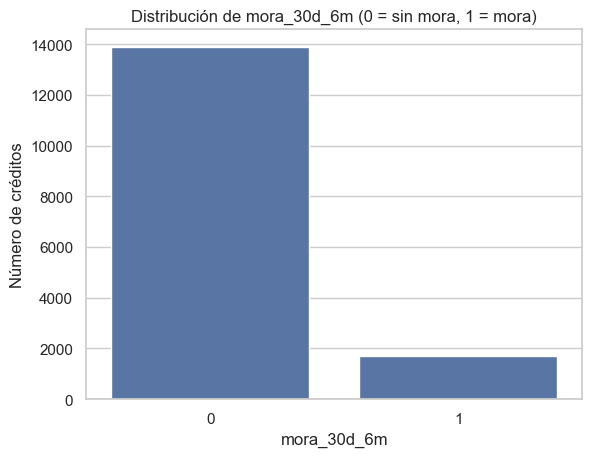

In [5]:
# Distribución de la variable objetivo
tabla = pd.DataFrame({
    "Créditos": df["mora_30d_6m"].value_counts(dropna=False),
    "%": (df["mora_30d_6m"].value_counts(normalize=True, dropna=False) * 100).round(2),
})
display(tabla)

tasa_mora = (df["mora_30d_6m"] == 1).mean()
print(f"Tasa de mora: {tasa_mora:.2%}")
print(f"Accuracy de un modelo que NUNCA predice mora: {1 - tasa_mora:.2%}")

sns.countplot(x=df["mora_30d_6m"].astype(str))
plt.title("Distribución de mora_30d_6m (0 = sin mora, 1 = mora)")
plt.xlabel("mora_30d_6m"); plt.ylabel("Número de créditos")
plt.show()

**Interpretación:**

*Lo que muestran los datos:* la variable objetivo está desbalanceada: cerca del 11 % de los créditos cae en mora (`mora_30d_6m = 1`), frente a cerca del 89 % que no (ver tabla). La variable no tiene valores faltantes y solo toma los valores 0 y 1.

*Lo que interpretamos (implicancias para el modelado):*
- Un modelo que nunca predice mora alcanzaría una accuracy cercana al 89 % (ver resultado de la celda) sin detectar un solo crédito en mora. Por eso la accuracy no es una métrica adecuada para este problema: puede ser alta aunque el modelo no cumpla su función.
- La evaluación deberá centrarse en la capacidad de detectar los créditos en mora: recall de la clase mora, AUC-PR y AUC-ROC, en línea con los criterios de utilidad de la sección 1, donde un falso negativo (aprobar a quien caerá en mora) es más costoso que un falso positivo.


### 3.2 Distribución de las variables numéricas

In [6]:
num_cols = ["monto_solicitado", "monto_aprobado", "ingreso_mensual_declarado",
            "gasto_mensual_declarado", "deuda_total_sistema", "cuota_mensual",
            "score_buro", "tasa_interes_anual", "edad", "antiguedad_negocio_meses",
            "max_dias_atraso_12m"]

# Copia numérica solo para analizar (no modifica df). Se documenta qué no se pudo convertir.
num = df[num_cols].apply(pd.to_numeric, errors="coerce")
no_conv = (num.isna() & df[num_cols].notna()).sum()
print("Valores no numéricos encontrados por columna:")
print(no_conv[no_conv > 0] if no_conv.sum() > 0 else "Ninguno")

res = num.describe(percentiles=[.01, .25, .5, .75, .99]).T
res["asimetría"] = num.skew()
res["media/mediana"] = res["mean"] / res["50%"]
display(res.round(2))

Valores no numéricos encontrados por columna:
ingreso_mensual_declarado    758
dtype: int64


,count,mean,std,min,1%,25%,50%,75%,99%,max,asimetría,media/mediana
monto_solicitado,15579.0,8924.79,7981.79,500.00,1000.00,3700.00,6500.00,11300.00,40800.00,60000.00,2.49,1.37
monto_aprobado,15579.0,8335.46,7609.24,400.00,900.00,3500.00,6100.00,10500.00,38900.00,67300.00,2.57,1.37
ingreso_mensual_declarado,14430.0,4224.80,4218.04,390.00,850.00,2250.00,3390.00,5110.00,15047.10,143100.00,11.91,1.25
gasto_mensual_declarado,14953.0,2246.12,1624.87,60.00,350.00,1150.00,1830.00,2860.00,8199.60,19880.00,2.26,1.23
deuda_total_sistema,15579.0,6270.75,10205.78,0.00,0.00,0.00,3090.00,8080.00,46797.60,155990.00,4.32,2.03
cuota_mensual,15579.0,787.16,651.36,31.60,127.12,381.86,613.21,960.67,3267.34,10224.27,3.04,1.28
score_buro,13162.0,620.21,111.56,300.00,358.00,545.00,621.50,696.00,879.39,950.00,-0.03,1.00
tasa_interes_anual,15579.0,57.63,9.74,0.29,23.28,53.06,58.44,63.52,75.65,85.64,-2.03,0.99
edad,15579.0,44.00,53.60,15.00,20.00,34.00,41.00,48.00,67.00,999.00,17.06,1.07
antiguedad_negocio_meses,14908.0,59.41,38.07,-1.00,7.00,34.00,50.00,75.00,195.00,365.00,1.75,1.19


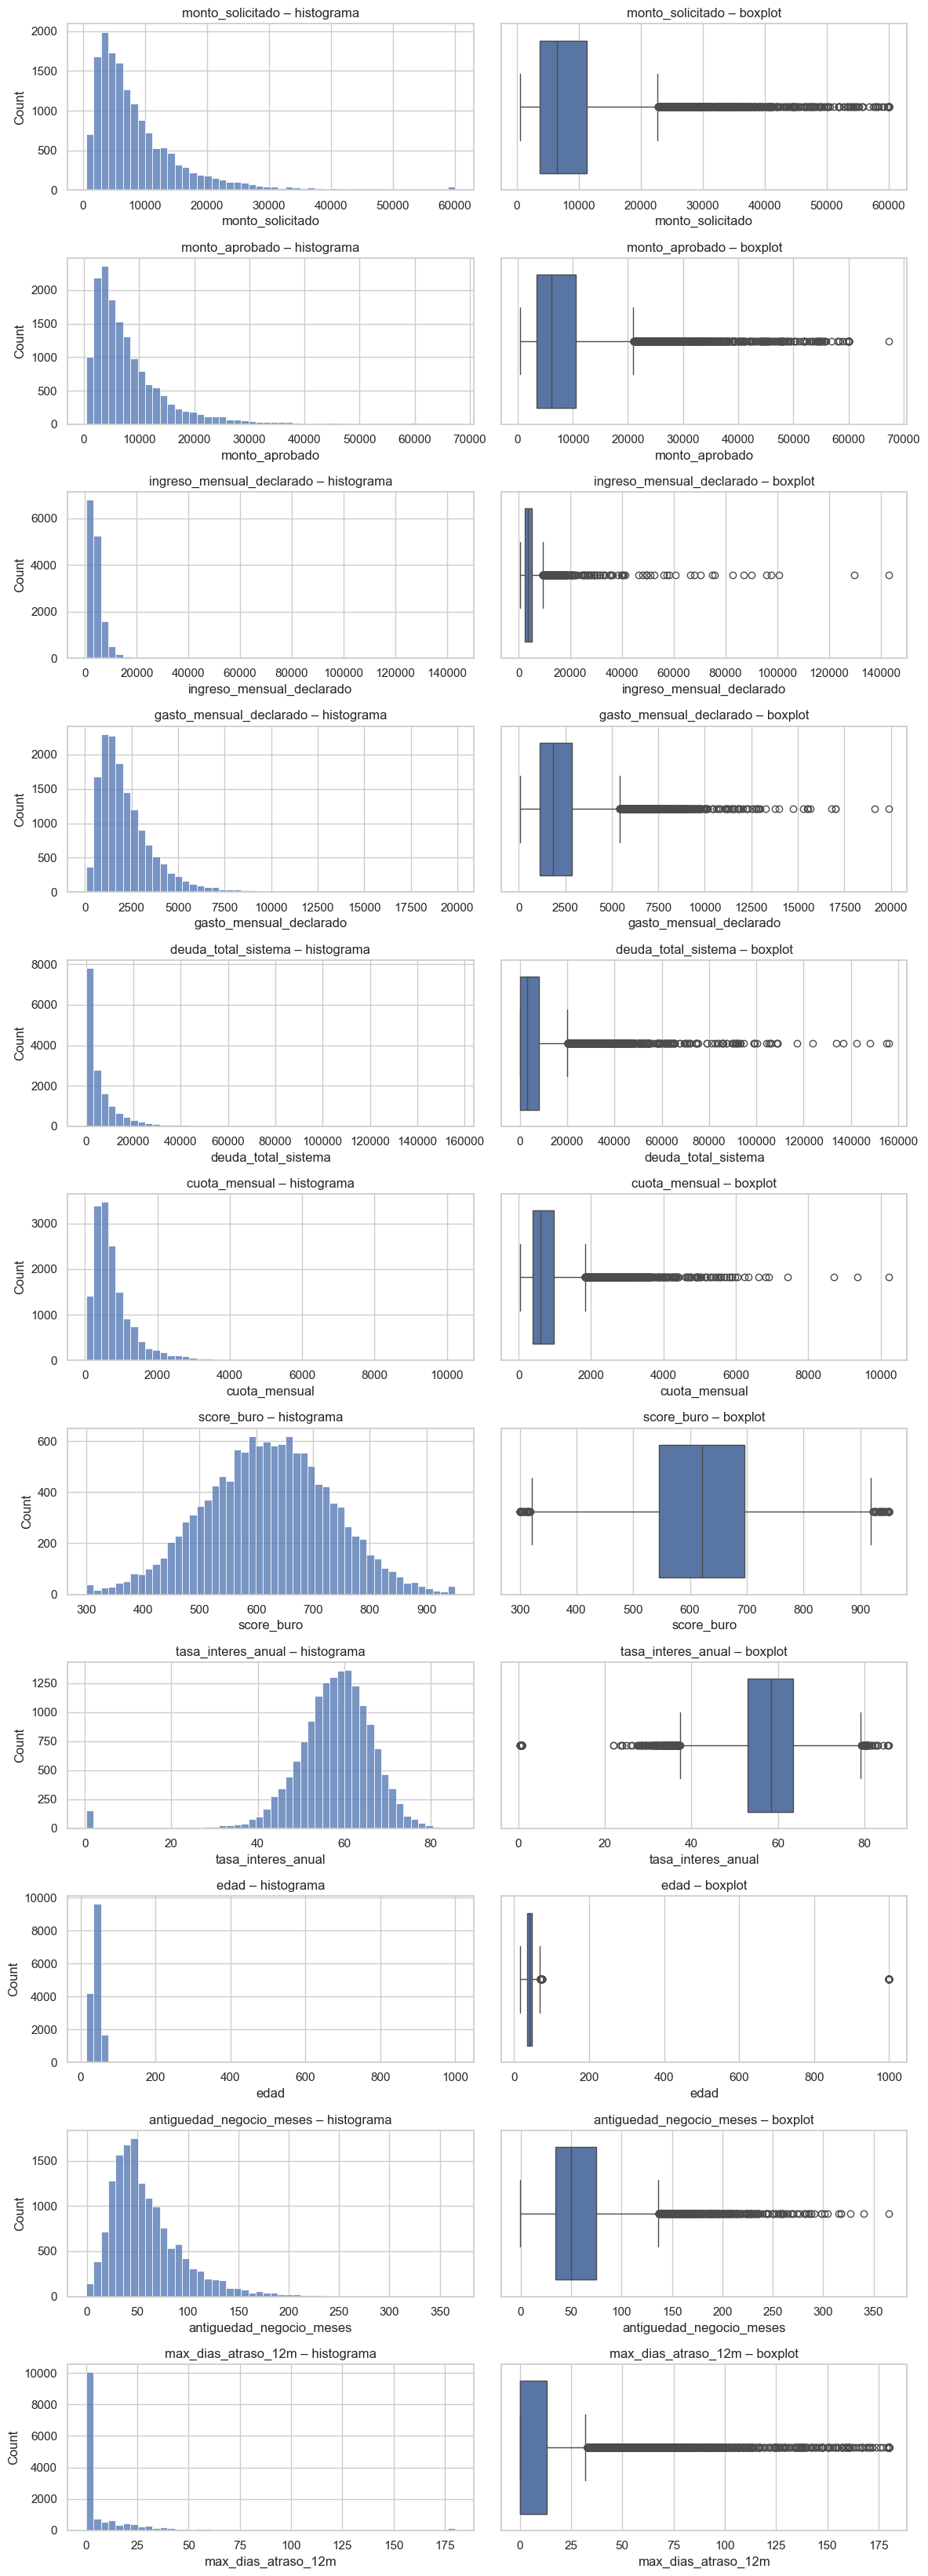

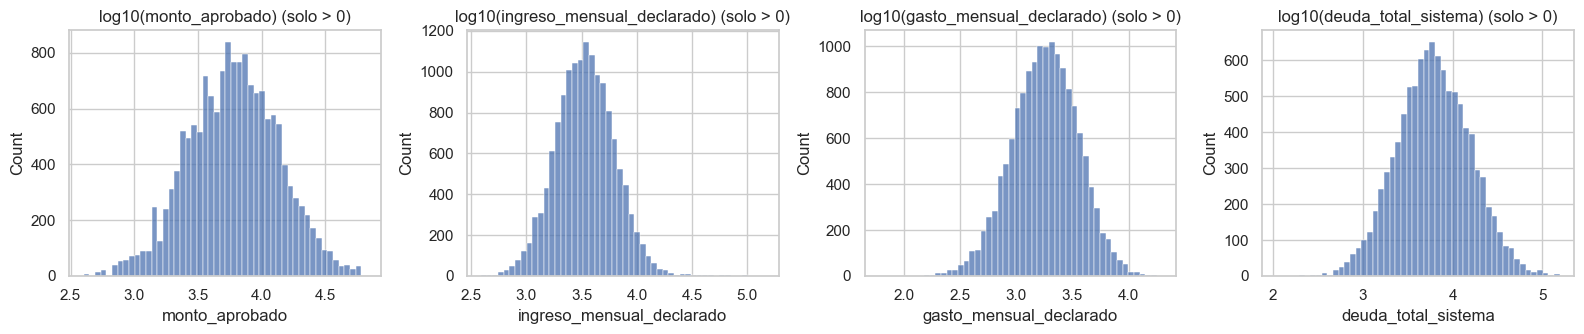

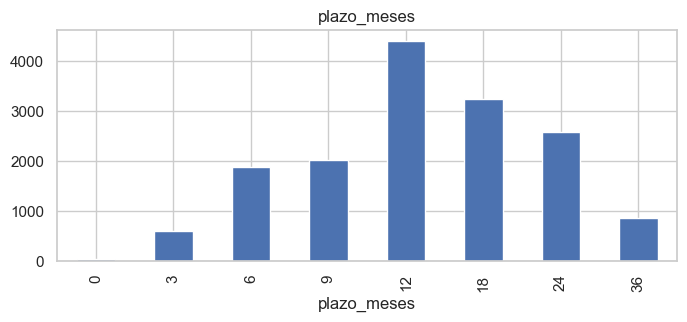

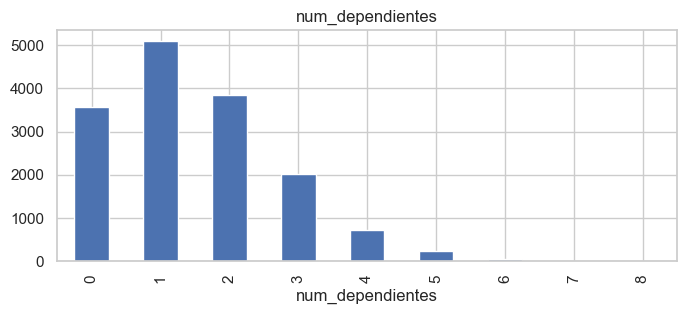

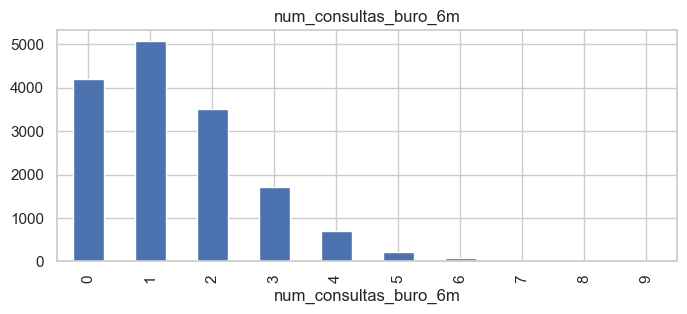

In [7]:
# Histograma + boxplot de cada variable numérica
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 3 * len(num_cols)))
for i, c in enumerate(num_cols):
    sns.histplot(num[c].dropna(), bins=50, ax=axes[i, 0])
    axes[i, 0].set_title(f"{c} – histograma")
    sns.boxplot(x=num[c].dropna(), ax=axes[i, 1])
    axes[i, 1].set_title(f"{c} – boxplot")
plt.tight_layout(); plt.show()

# Variables monetarias en escala logarítmica (solo valores > 0) para ver mejor su forma
monetarias = ["monto_aprobado", "ingreso_mensual_declarado", "gasto_mensual_declarado", "deuda_total_sistema"]
fig, axes = plt.subplots(1, len(monetarias), figsize=(16, 3.5))
for ax, c in zip(axes, monetarias):
    sns.histplot(np.log10(num[c][num[c] > 0]), bins=50, ax=ax)
    ax.set_title(f"log10({c}) (solo > 0)")
plt.tight_layout(); plt.show()

# Variables discretas: conteo de cada valor
for c in ["plazo_meses", "num_dependientes", "num_consultas_buro_6m"]:
    df[c].value_counts(dropna=False).sort_index().plot(kind="bar", figsize=(8, 3), title=c)
    plt.show()

In [8]:
# Conteo de valores imposibles o sospechosos (reglas del diccionario y del negocio)
plazo = pd.to_numeric(df["plazo_meses"], errors="coerce")
chequeos = {
    "edad menor a 18": (num["edad"] < 18).sum(),
    "edad mayor a 100 (p. ej. 999)": (num["edad"] > 100).sum(),
    "antigüedad del negocio negativa": (num["antiguedad_negocio_meses"] < 0).sum(),
    "tasa de interés menor a 5 (posible escala 0-1)": (num["tasa_interes_anual"] < 5).sum(),
    "plazo igual a 0 meses": (plazo == 0).sum(),
    "monto_aprobado > monto_solicitado": (num["monto_aprobado"] > num["monto_solicitado"]).sum(),
    "gasto declarado > ingreso declarado": (num["gasto_mensual_declarado"] > num["ingreso_mensual_declarado"]).sum(),
    "score_buro fuera del rango 300-950": ((num["score_buro"] < 300) | (num["score_buro"] > 950)).sum(),
}
display(pd.Series(chequeos, name="Casos").to_frame())

ing = df["ingreso_mensual_declarado"]
print("Ejemplos de ingresos no numéricos:", ing[num["ingreso_mensual_declarado"].isna() & ing.notna()].head(10).tolist())

,Casos
edad menor a 18,30
edad mayor a 100 (p. ej. 999),47
antigüedad del negocio negativa,47
tasa de interés menor a 5 (posible escala 0-1),154
plazo igual a 0 meses,30
monto_aprobado > monto_solicitado,123
gasto declarado > ingreso declarado,0
score_buro fuera del rango 300-950,0


Ejemplos de ingresos no numéricos: ['S/ 1,470.00', 'S/ 1,760.00', 'S/ 4,530.00', 'S/ 3,030.00', 'S/ 1,800.00', 'S/ 4,620.00', 'S/ 1,870.00', 'S/ 5,630.00', 'S/ 3,610.00', 'S/ 10,080.00']


**Interpretación:**

*Lo que muestran los datos:*
- Las variables monetarias (`monto_solicitado`, `monto_aprobado`, `ingreso_mensual_declarado`, `gasto_mensual_declarado`, `deuda_total_sistema`, `cuota_mensual`) tienen distribuciones asimétricas a la derecha: la media es mayor que la mediana  y hay valores muy alejados del resto (boxplots). En escala logarítmica adoptan una forma aproximadamente simétrica.
- `deuda_total_sistema` y `max_dias_atraso_12m` concentran muchos ceros: al menos una cuarta parte de los clientes no tiene deuda en el sistema y al menos la mitad no registró atrasos en los últimos 12 meses.
- `score_buro` respeta el rango 300–950 del diccionario y tiene una distribución casi simétrica, con pequeñas acumulaciones en los dos extremos de la escala.
- `plazo_meses` toma valores discretos (3, 6, 9, 12, 18, 24 y 36 meses), siendo 12 el más frecuente. `num_dependientes` y `num_consultas_buro_6m` se concentran entre 0 y 2, sin valores anómalos.
- La tabla de chequeos muestra valores imposibles o sospechosos: edades menores a 18 y edades de 999, antigüedad del negocio negativa, un grupo de tasas de interés cercanas a 0 separado del resto, plazos de 0 meses y créditos con monto aprobado mayor al solicitado. La regla "gasto ≤ ingreso" se cumple en todos los casos comparables.
- `ingreso_mensual_declarado` contiene valores escritos con formato de moneda (por ejemplo, `S/ 1,470.00`), por lo que no se lee como numérica.

*Lo que interpretamos:*
- En las variables monetarias la media no basta: está inflada por unos pocos valores muy altos. La mediana y el rango intercuartílico describen mejor el caso típico. Para el modelado podría convenir una transformación logarítmica.
- Los valores altos de montos e ingresos pueden ser casos reales (negocios más grandes) o errores de registro; los datos no permiten distinguirlos sin una regla de negocio, por lo que no se eliminan en esta etapa.
- Las edades de 999 y la antigüedad negativa parecen códigos de "dato desconocido" más que valores reales (hipótesis). Las edades menores a 18 son incompatibles con un crédito formal.
- El grupo de tasas cercanas a 0 sugiere un error de escala: tasas registradas como proporción (por ejemplo, 0.58) en lugar de porcentaje (58) (hipótesis).
- Un plazo de 0 meses no tiene sentido para un crédito, y un monto aprobado mayor al solicitado contradice la lógica habitual de aprobación; ambos se registran como inconsistencias.
- Los ingresos con formato `S/ 1,470.00` son recuperables: el valor existe, solo cambia el formato.


### 3.3 Distribución de las variables categóricas

In [9]:
cat_cols = ["region", "canal_captacion", "sexo", "estado_civil", "nivel_educativo",
            "tipo_vivienda", "rubro", "cliente_recurrente", "calificacion_sbs",
            "tiene_garantia", "telefono_verificado"]

resumen_cat = pd.DataFrame({
    "categorías (crudas)": {c: df[c].nunique() for c in cat_cols},
    "categorías (sin mayúsc./espacios)": {c: df[c].dropna().astype(str).str.strip().str.lower().nunique() for c in cat_cols},
    "% faltantes": {c: round(df[c].isna().mean() * 100, 2) for c in cat_cols},
    "% de la categoría más rara": {c: round(df[c].value_counts(normalize=True).min() * 100, 2) for c in cat_cols},
})
display(resumen_cat)

print("codigo_asesor – número de asesores distintos:", df["codigo_asesor"].nunique())
display(df["codigo_asesor"].value_counts().head(10).to_frame("Créditos"))

# Reglas de coherencia tomadas del diccionario
canal = df["canal_captacion"].astype(str).str.strip().str.lower()
asesor = df["codigo_asesor"].astype(str).str.strip().str.upper()
recurrente = df["cliente_recurrente"].astype(str).str.strip().str.lower()
previos = pd.to_numeric(df["num_creditos_previos_entidad"], errors="coerce")
print("Canal digital pero con asesor asignado:", ((canal == "digital") & (asesor != "DIGITAL")).sum())
print("Asesor DIGITAL pero canal no digital:", ((canal != "digital") & (asesor == "DIGITAL")).sum())
print("Cliente NO recurrente pero con créditos previos:", ((recurrente == "no") & (previos > 0)).sum())

,categorías (crudas),categorías (sin mayúsc./espacios),% faltantes,% de la categoría más rara
region,25,12,0.00,0.47
canal_captacion,3,3,0.00,12.35
sexo,4,4,0.00,19.01
estado_civil,5,5,0.00,3.89
nivel_educativo,4,4,8.25,12.51
tipo_vivienda,3,3,0.00,23.76
rubro,16,9,0.00,0.56
cliente_recurrente,2,2,0.00,25.26
calificacion_sbs,6,6,0.00,1.60
tiene_garantia,2,2,0.00,25.10


codigo_asesor – número de asesores distintos: 45


,Créditos
codigo_asesor,
DIGITAL,1924
AS039,721
AS026,712
AS004,680
AS032,611
AS020,586
AS022,583
AS012,575
AS008,556


Canal digital pero con asesor asignado: 0
Asesor DIGITAL pero canal no digital: 0
Cliente NO recurrente pero con créditos previos: 0



=== region ===


,Créditos,%
region,,
Lima,3955,25.39
Piura,1575,10.11
Arequipa,1344,8.63
La Libertad,1343,8.62
Junin,1238,7.95
Cusco,1065,6.84
Lambayeque,1051,6.75
Puno,957,6.14
Loreto,867,5.57


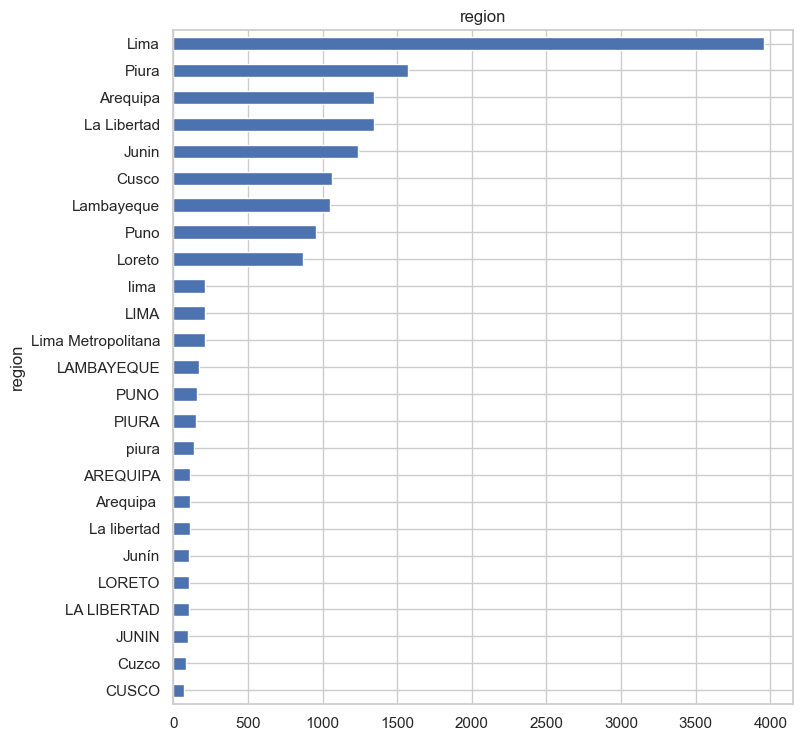


=== canal_captacion ===


,Créditos,%
canal_captacion,,
Asesor de campo,8253,52.98
Agencia,5402,34.67
Digital,1924,12.35


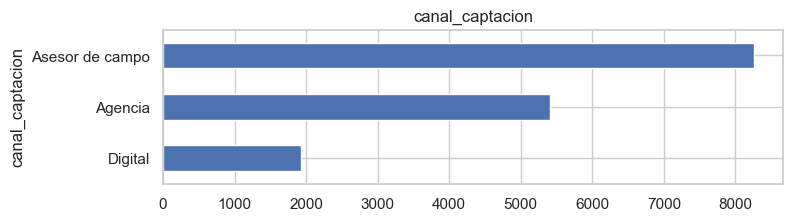


=== sexo ===


,Créditos,%
sexo,,
Femenino,4888,31.38
Masculino,3981,25.55
F,3748,24.06
M,2962,19.01


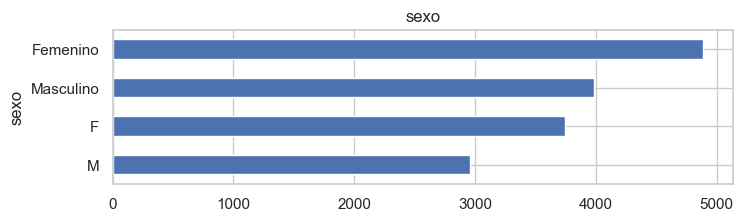


=== estado_civil ===


,Créditos,%
estado_civil,,
Soltero,4803,30.83
Conviviente,4659,29.91
Casado,4599,29.52
Divorciado,912,5.85
Viudo,606,3.89


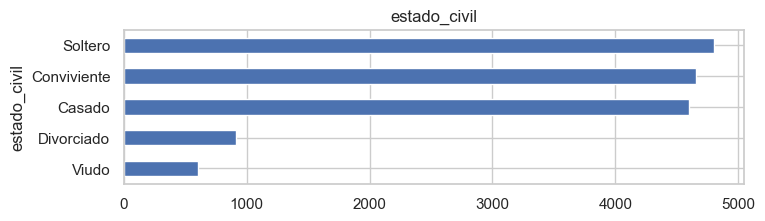


=== nivel_educativo ===


,Créditos,%
nivel_educativo,,
Secundaria,6795,43.62
Tecnica,3086,19.81
Primaria,2625,16.85
Universitaria,1788,11.48
(vacío),1285,8.25


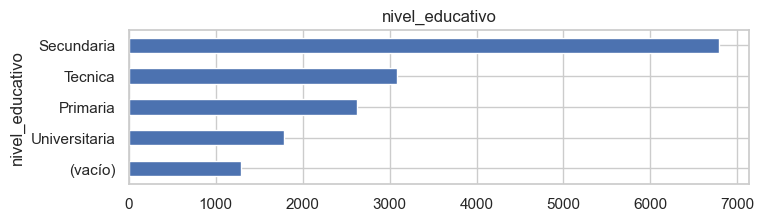


=== tipo_vivienda ===


,Créditos,%
tipo_vivienda,,
Propia,6398,41.07
Familiar,5480,35.18
Alquilada,3701,23.76


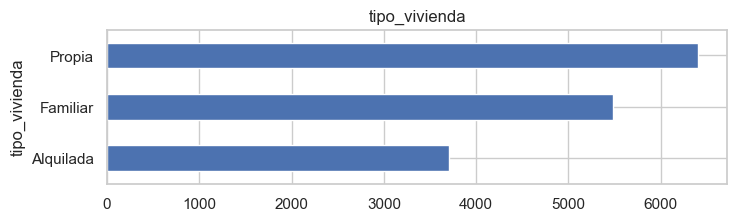


=== rubro ===


,Créditos,%
rubro,,
Comercio,6165,39.57
Servicios,2824,18.13
Agropecuario,1701,10.92
Produccion,1672,10.73
Transporte,1662,10.67
COMERCIO,237,1.52
comercio,235,1.51
Comerc.,205,1.32
Servicio,163,1.05


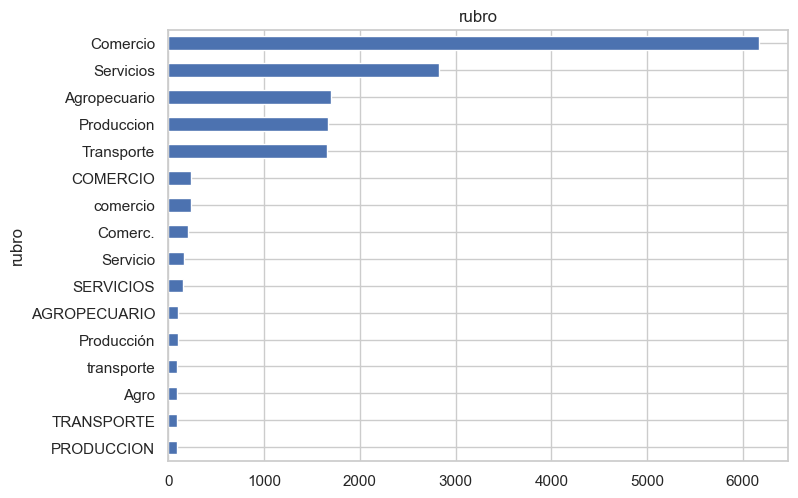


=== cliente_recurrente ===


,Créditos,%
cliente_recurrente,,
No,11643,74.74
Si,3936,25.26


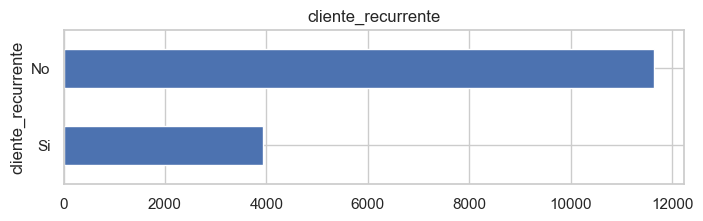


=== calificacion_sbs ===


,Créditos,%
calificacion_sbs,,
Normal,9930,63.74
Sin historial,2417,15.51
CPP,1766,11.34
Deficiente,802,5.15
Dudoso,414,2.66
Perdida,250,1.60


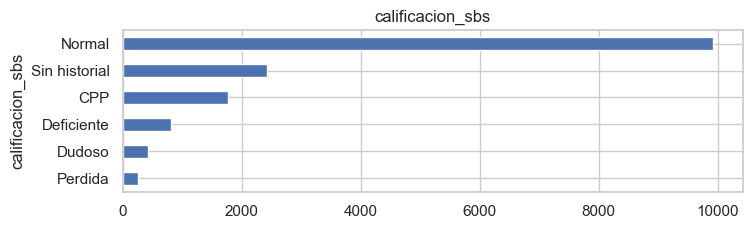


=== tiene_garantia ===


,Créditos,%
tiene_garantia,,
No,11668,74.9
Si,3911,25.1


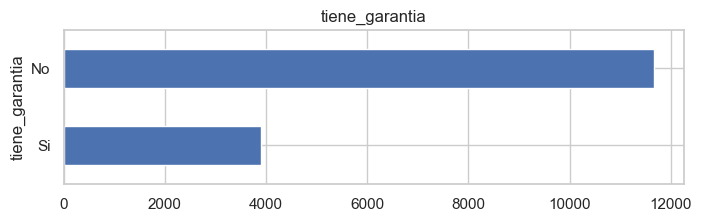


=== telefono_verificado ===


,Créditos,%
telefono_verificado,,
Si,12976,83.29
No,2137,13.72
(vacío),466,2.99


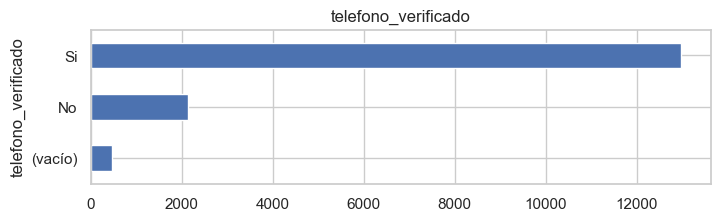

In [10]:
for c in cat_cols:
    conteo = df[c].fillna("(vacío)").value_counts()
    print(f"\n=== {c} ===")
    display(pd.DataFrame({"Créditos": conteo, "%": (conteo / len(df) * 100).round(2)}))
    conteo.sort_values().plot(kind="barh", figsize=(8, max(2, 0.35 * len(conteo))), title=c)
    plt.show()

In [11]:
# ¿Los score_buro vacíos coinciden con la categoría "Sin historial"?
score_estado = df["score_buro"].isna().map({True: "score vacío", False: "score presente"})
display(pd.crosstab(df["calificacion_sbs"], score_estado))

score_buro,score presente,score vacío
calificacion_sbs,,
CPP,1766,0
Deficiente,802,0
Dudoso,414,0
Normal,9930,0
Perdida,250,0
Sin historial,0,2417


**Interpretación:**

*Lo que muestran los datos:*
- `region` y `rubro` tienen muchas más categorías escritas que categorías reales (ver tabla resumen y gráficos). Las variantes combinan mayúsculas y minúsculas (`Lima`, `LIMA`, `lima`), espacios al final (`Arequipa `), tildes (`Junín` / `Junin`, `Producción` / `Produccion`), abreviaturas (`Comerc.`, `Agro`), singular y plural (`Servicio` / `Servicios`) y grafías alternativas (`Cuzco` / `Cusco`). En la práctica corresponden a 9 regiones (10 si `Lima Metropolitana` se considera distinta de `Lima`) y 5 rubros.
- `region` incluye además `Lima Metropolitana`, que podría ser la misma categoría que `Lima` o una zona distinta.
- `sexo` tiene 4 valores para 2 categorías reales: `Femenino` / `F` y `Masculino` / `M`. Las abreviaturas representan una parte importante de los registros, no casos aislados.
- Las categorías con menos del 1 % de los registros corresponden a estas variantes mal escritas, no a grupos realmente pequeños.
- `calificacion_sbs` tiene 6 categorías: las 5 de la clasificación SBS (Normal, CPP, Deficiente, Dudoso, Pérdida) más `Sin historial`. Los créditos con `score_buro` vacío coinciden exactamente con la categoría `Sin historial` (ver tabla cruzada).
- `nivel_educativo` y `telefono_verificado` tienen valores faltantes; las demás variables categóricas no.
- `codigo_asesor` tiene 45 códigos distintos, incluido `DIGITAL` para los créditos sin asesor. Las tres reglas de coherencia revisadas (canal digital sin asesor, asesor DIGITAL solo en canal digital, cliente no recurrente sin créditos previos) se cumplen en todos los registros.

*Lo que interpretamos:*
- Las inconsistencias de escritura dividen artificialmente un mismo grupo en varias categorías. Sin unificarlas, un modelo trataría `Lima` y `LIMA` como grupos distintos y las tasas de mora por región o rubro serían engañosas. Se unificarán en el notebook 02.
- Fusionar o no `Lima Metropolitana` con `Lima` es una decisión de criterio que el grupo debe justificar, no una corrección evidente.
- La coincidencia exacta entre `score_buro` vacío y `Sin historial` muestra que esos faltantes no son aleatorios: corresponden a clientes sin historial crediticio. Imputarlos con la mediana borraría esa información; conviene conservarla, por ejemplo con una variable indicadora.
- `codigo_asesor` tiene muchas categorías; su uso en el modelo requerirá una codificación adecuada para no generar demasiadas columnas.
- Ninguno de estos problemas se corrige aquí: se registran en la tabla de la sección 3.8.

### 3.4 Relación de las variables con la mora


#### 3.4.1 Pregunta: 

In [ ]:
# Guía: boxplot por clase o tasa de mora por cuantiles (pd.qcut + groupby)

**Interpretación:**

#### 3.4.2 Pregunta: 

In [ ]:
# Guía: groupby(variable)['mora_30d_6m'].mean() o pd.crosstab(..., normalize='index')

**Interpretación:**

#### 3.4.3 Pregunta: 

In [ ]:
# Guía: otra variable que consideren relevante para el problema

**Interpretación:**

### 3.5 Diferencias entre grupos

#### Pregunta: 

In [ ]:
# Guía: tasa de mora por región, rubro y/o canal de captación

**Interpretación:**

### 3.6 Evolución en el tiempo

#### Pregunta: 

In [ ]:
# Guía: tasa de mora por mes o trimestre de desembolso (requiere fechas bien convertidas)

**Interpretación:**

> Guía: ¿lo que vean aquí debería influir en cómo separar train, validation y test?

### 3.7 Relaciones entre variables explicativas

In [ ]:
# Guía: matriz de correlación (sns.heatmap) o scatterplot entre variables numéricas

**Interpretación:**

### 3.8 Patrones, anomalías y problemas de calidad observados

| Hallazgo | Evidencia | Posible explicación | Decisión que condiciona |
|---|---|---|---|
| | | | |
| | | | |

### 3.9 Síntesis del EDA

- **Hallazgos principales:**
- **Variables que parecen más relacionadas con la mora** (y la precaución al afirmarlo):
- **Implicancias para la preparación y el modelado:**
- **Lo que aún no puede concluirse:**